# POS delay - sensitivity analysis

Questo notebook valuta la robustezza del detector POS delay utilizzando una configurazione fissata a priori e definita in `POS_delay_utils.py`.

La configurazione del detector è:

```python
score_col = "pos_cos"
profile_window_size = 7
z_threshold = 3.5
min_consecutive = 2
gap_tolerance = 1
detected_window_mode = "profile_windows_union"
iou_threshold = 0.20
```

La configurazione non viene ritarata in questo notebook. L'obiettivo non è selezionare nuovi iperparametri usando la ground truth del test, ma valutare il comportamento del detector POS delay su dataset diversi mantenendo fissa la stessa pipeline di rilevazione.

L'analisi è organizzata in due parti:

- analisi principale sui dataset con `source_duration = 1`;
- analisi secondaria sui dataset con `source_duration = 1, 2, 3`, usata per valutare l'effetto della durata dell'evento sorgente.

Per ogni dataset viene eseguita l'inference del modello LSTM POS già addestrato. A partire dalle previsioni ottenute, vengono costruite finestre di profilo sui business days e viene calcolato lo score `pos_cos`, che misura la differenza tra il profilo POS osservato e quello atteso.

La soglia di detection è stimata sul validation set tramite z-score store-specific, mentre la valutazione finale è effettuata a livello evento sulle effect windows, cioè sui giorni in cui il ritardo di settlement è osservabile in `pos_net_cf`.

In [1]:
# =========================================================
# PATH
# =========================================================

import sys
from pathlib import Path

start_dir = Path.cwd().resolve()

for candidate in [start_dir, *start_dir.parents]:
    if (candidate / "project_paths.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Root del progetto non trovata. "
        "Avvia Jupyter da una cartella interna alla repository."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/Users/ciok4/jupyter file/tesi')

In [2]:
# =========================================================
# IMPORTS
# =========================================================

import json
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from IPython.display import display
from tqdm.auto import tqdm

from project_paths import (
    POS_DELAY_RESULTS_DIR,
    POS_DELAY_SENSITIVITY_DIR,
    POS_MODEL_DIR,
    ensure_artifact_directories,
)

from POS_delay_utils import (
    POS_DELAY_DETECTOR_CONFIG,
    add_detection_offsets,
    compute_results_for_dataset,
    list_pos_delay_sensitivity_datasets,
    make_empty_event_summary,
    make_pos_delay_cache_path,
    pooled_f1,
    pooled_precision,
    pooled_recall,
    run_detector_config_on_results,
)

pd.set_option("display.max_columns", None)

In [3]:
# =========================================================
# CONFIG
# =========================================================

ensure_artifact_directories()

BASE_SENSITIVITY_PATH = POS_DELAY_SENSITIVITY_DIR
MODEL_DIR = POS_MODEL_DIR

OUTPUT_DIR = POS_DELAY_RESULTS_DIR / "lstm_sensitivity"
INFERENCE_CACHE_DIR = OUTPUT_DIR / "_inference_cache"
DETECTOR_CACHE_DIR = OUTPUT_DIR / "_detector_cache"
FIGURES_DIR = OUTPUT_DIR / "figures"

for path in [
    OUTPUT_DIR,
    INFERENCE_CACHE_DIR,
    DETECTOR_CACHE_DIR,
    FIGURES_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

SUMMARY_PATH = OUTPUT_DIR / "pos_delay_sensitivity_best_detector_results.csv"
GT_EVAL_PATH = OUTPUT_DIR / "pos_delay_sensitivity_gt_eval.csv"
DET_EVAL_PATH = OUTPUT_DIR / "pos_delay_sensitivity_det_eval.csv"
RAW_RESULTS_MANIFEST_PATH = (
    OUTPUT_DIR / "pos_delay_sensitivity_cache_manifest.json"
)

CACHE_SCHEMA_VERSION = 1

# L'analisi principale usa source_duration = 1.
# Le durate 2 e 3 sono incluse per l'analisi secondaria.
SOURCE_DURATION_FILTER = [1, 2, 3]
SOURCE_DURATION_ORDER = [1, 2, 3]

DELAY_TYPES_FILTER = [
    "mild_delay",
    "moderate_delay",
    "strong_delay",
    "batch_backlog",
    "settlement_freeze",
]

DELAY_TYPE_ORDER = [
    "mild_delay",
    "moderate_delay",
    "strong_delay",
    "batch_backlog",
    "settlement_freeze",
]

# Finestra temporale del modello LSTM POS già addestrato.
WINDOW_SIZE = 7

# Se True, ignora tutte le cache e rigenera inference, detector e risultati raw.
FORCE_RECOMPUTE = False

# Configurazione fissa del detector POS delay.
CONFIG = POS_DELAY_DETECTOR_CONFIG.copy()

print("PROJECT_ROOT:", PROJECT_ROOT)
print("BASE_SENSITIVITY_PATH:", BASE_SENSITIVITY_PATH)
print("MODEL_DIR:", MODEL_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("INFERENCE_CACHE_DIR:", INFERENCE_CACHE_DIR)
print("Detector config:")
print(CONFIG)

PROJECT_ROOT: C:\Users\ciok4\jupyter file\tesi
BASE_SENSITIVITY_PATH: C:\Users\ciok4\jupyter file\tesi\artifacts\data\datasets\pos_delay\sensitivity
MODEL_DIR: C:\Users\ciok4\jupyter file\tesi\artifacts\models\pos
OUTPUT_DIR: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\lstm_sensitivity
INFERENCE_CACHE_DIR: C:\Users\ciok4\jupyter file\tesi\artifacts\results\pos_delay\lstm_sensitivity\_inference_cache
Detector config:
{'score_col': 'pos_cos', 'profile_window_size': 7, 'z_threshold': 3.5, 'min_consecutive': 2, 'gap_tolerance': 1, 'detected_window_mode': 'profile_windows_union', 'iou_threshold': 0.2}


In [4]:
# =========================================================
# LOAD MODEL AND PREPROCESSING OBJECTS
# =========================================================

model = None
feature_scalers = None
mappings = None
features = None


def load_pos_model_artifacts():
    """Carica il modello POS e gli artifact di preprocessing una sola volta."""

    global model, feature_scalers, mappings, features

    if model is not None:
        return

    model = tf.keras.models.load_model(
        MODEL_DIR / "lstm_pos.keras"
    )

    with open(MODEL_DIR / "feature_scalers.pkl", "rb") as f:
        feature_scalers = pickle.load(f)

    with open(MODEL_DIR / "mappings.pkl", "rb") as f:
        mappings = pickle.load(f)

    with open(MODEL_DIR / "features.pkl", "rb") as f:
        features = pickle.load(f)

## Dataset di sensitivity

I dataset sono attesi nella struttura:

```text
sensitivity /
    delay_type /
        srcdur_<source_duration> /
            seed_<seed> /
                all_stores_cashflow.csv
```

In [5]:
# =========================================================
# LIST DATASETS
# =========================================================

datasets_df = list_pos_delay_sensitivity_datasets(
    BASE_SENSITIVITY_PATH,
    source_duration_filter=SOURCE_DURATION_FILTER,
    delay_types_filter=DELAY_TYPES_FILTER,
)

display(datasets_df)

,path,delay_type,source_duration,seed
0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,42
1,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,43
2,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,44
3,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,45
4,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,batch_backlog,1,46
...,...,...,...,...
70,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,strong_delay,3,42
71,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,strong_delay,3,43
72,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,strong_delay,3,44
73,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,strong_delay,3,45


In [6]:
# Copertura degli esperimenti disponibili.
experiment_coverage = (
    datasets_df
    .groupby(["source_duration", "delay_type"])
    .size()
    .rename("n_datasets")
    .reset_index()
)

display(experiment_coverage)

,source_duration,delay_type,n_datasets
0,1,batch_backlog,5
1,1,mild_delay,5
2,1,moderate_delay,5
3,1,settlement_freeze,5
4,1,strong_delay,5
5,2,batch_backlog,5
6,2,mild_delay,5
7,2,moderate_delay,5
8,2,settlement_freeze,5
9,2,strong_delay,5


## Runner del singolo dataset

Per ogni dataset vengono eseguiti quattro passaggi:

1. inference del modello LSTM POS;
2. costruzione degli score di profilo;
3. applicazione del detector con configurazione fissa;
4. valutazione event-level e calcolo degli offset tra finestra rilevata e
   finestra ground truth.

In [7]:
# =========================================================
# SINGLE DATASET RUNNER
# =========================================================

def _path_state(path):
    path = Path(path)

    if not path.exists():
        return {
            "path": str(path.resolve()),
            "exists": False,
        }

    stat = path.stat()

    return {
        "path": str(path.resolve()),
        "exists": True,
        "mtime_ns": int(stat.st_mtime_ns),
        "size_bytes": int(stat.st_size),
    }


def _dataset_state(dataset_row):
    return {
        "delay_type": str(dataset_row["delay_type"]),
        "source_duration": int(dataset_row["source_duration"]),
        "seed": int(dataset_row["seed"]),
        "file": _path_state(dataset_row["path"]),
    }


def _model_artifact_states():
    artifact_paths = [
        MODEL_DIR / "lstm_pos.keras",
        MODEL_DIR / "feature_scalers.pkl",
        MODEL_DIR / "mappings.pkl",
        MODEL_DIR / "features.pkl",
    ]

    return [_path_state(path) for path in artifact_paths]


def _latest_mtime_ns(states):
    timestamps = [
        state["mtime_ns"]
        for state in states
        if state.get("exists")
    ]

    return max(timestamps, default=-1)


def _cache_is_newer_than_dependencies(cache_path, dependency_states):
    if not cache_path.exists():
        return False

    return cache_path.stat().st_mtime_ns >= _latest_mtime_ns(
        dependency_states
    )


def _inference_cache_metadata(dataset_row):
    return {
        "schema_version": CACHE_SCHEMA_VERSION,
        "window_size": int(WINDOW_SIZE),
        "dataset": _dataset_state(dataset_row),
        "model_artifacts": _model_artifact_states(),
    }


def _detector_cache_metadata(dataset_row):
    return {
        "schema_version": CACHE_SCHEMA_VERSION,
        "inference": _inference_cache_metadata(dataset_row),
        "detector_config": CONFIG.copy(),
    }


def _results_cache_metadata(datasets):
    dataset_states = [
        _dataset_state(dataset_row)
        for _, dataset_row in datasets.iterrows()
    ]

    return {
        "schema_version": CACHE_SCHEMA_VERSION,
        "window_size": int(WINDOW_SIZE),
        "detector_config": CONFIG.copy(),
        "datasets": dataset_states,
        "model_artifacts": _model_artifact_states(),
    }


def _load_cache_payload(cache_path, expected_metadata, dependencies):
    if FORCE_RECOMPUTE or not cache_path.exists():
        return None

    try:
        with open(cache_path, "rb") as f:
            cached_object = pickle.load(f)
    except (OSError, EOFError, pickle.UnpicklingError):
        return None

    is_wrapped_cache = (
        isinstance(cached_object, dict)
        and "metadata" in cached_object
        and "payload" in cached_object
    )

    if (
        is_wrapped_cache
        and cached_object["metadata"] == expected_metadata
    ):
        return cached_object["payload"]

    if is_wrapped_cache:
        return None

    if _cache_is_newer_than_dependencies(cache_path, dependencies):
        with open(cache_path, "wb") as f:
            pickle.dump(
                {
                    "metadata": expected_metadata,
                    "payload": cached_object,
                },
                f,
            )

        return cached_object

    return None


def _save_cache_payload(cache_path, metadata, payload):
    with open(cache_path, "wb") as f:
        pickle.dump(
            {
                "metadata": metadata,
                "payload": payload,
            },
            f,
        )


def _detector_cache_path(dataset_row):
    base_name = make_pos_delay_cache_path(
        dataset_row,
        DETECTOR_CACHE_DIR,
    ).stem

    config_token = (
        f"{CONFIG['score_col']}_w{CONFIG['profile_window_size']}"
        f"_z{CONFIG['z_threshold']}_m{CONFIG['min_consecutive']}"
        f"_g{CONFIG['gap_tolerance']}_iou{CONFIG['iou_threshold']}"
    ).replace(".", "p")

    return DETECTOR_CACHE_DIR / f"{base_name}_{config_token}.pkl"


def _result_cache_key_frame(df):
    required_columns = [
        "delay_type",
        "source_duration",
        "seed",
        "score_col",
        "profile_window_size",
        "z_threshold",
        "min_consecutive",
        "gap_tolerance",
        "detected_window_mode",
        "iou_threshold",
    ]

    if not set(required_columns).issubset(df.columns):
        return None

    out = df[required_columns].copy()

    for column in [
        "source_duration",
        "seed",
        "profile_window_size",
        "min_consecutive",
        "gap_tolerance",
    ]:
        out[column] = pd.to_numeric(out[column], errors="coerce").astype("Int64")

    for column in ["z_threshold", "iou_threshold"]:
        out[column] = pd.to_numeric(out[column], errors="coerce").round(12)

    for column in [
        "delay_type",
        "score_col",
        "detected_window_mode",
    ]:
        out[column] = out[column].astype(str)

    return (
        out
        .drop_duplicates()
        .sort_values(required_columns)
        .reset_index(drop=True)
    )


def _expected_result_cache_keys(datasets):
    expected = datasets[
        ["delay_type", "source_duration", "seed"]
    ].copy()

    expected["score_col"] = CONFIG["score_col"]
    expected["profile_window_size"] = CONFIG["profile_window_size"]
    expected["z_threshold"] = CONFIG["z_threshold"]
    expected["min_consecutive"] = CONFIG["min_consecutive"]
    expected["gap_tolerance"] = CONFIG["gap_tolerance"]
    expected["detected_window_mode"] = CONFIG.get(
        "detected_window_mode",
        "profile_windows_union",
    )
    expected["iou_threshold"] = CONFIG["iou_threshold"]

    return _result_cache_key_frame(expected)


def _read_csv_or_empty(path):
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


def raw_results_cache_is_complete(datasets):
    required_paths = [
        SUMMARY_PATH,
        GT_EVAL_PATH,
        DET_EVAL_PATH,
    ]

    if not all(path.exists() for path in required_paths):
        return False

    try:
        cached_summary = pd.read_csv(SUMMARY_PATH)
        _read_csv_or_empty(GT_EVAL_PATH)
        _read_csv_or_empty(DET_EVAL_PATH)
    except (OSError, pd.errors.ParserError):
        return False

    expected_keys = _expected_result_cache_keys(datasets)
    cached_keys = _result_cache_key_frame(cached_summary)

    if cached_keys is None or not cached_keys.equals(expected_keys):
        return False

    if len(cached_summary) != len(expected_keys):
        return False

    current_metadata = _results_cache_metadata(datasets)

    if RAW_RESULTS_MANIFEST_PATH.exists():
        try:
            with open(RAW_RESULTS_MANIFEST_PATH, "r", encoding="utf-8") as f:
                cached_metadata = json.load(f)
        except (OSError, json.JSONDecodeError):
            return False

        return cached_metadata == current_metadata

    dependency_states = [
        *[_dataset_state(dataset_row)["file"] for _, dataset_row in datasets.iterrows()],
        *_model_artifact_states(),
    ]

    return all(
        _cache_is_newer_than_dependencies(path, dependency_states)
        for path in required_paths
    )


def save_raw_results_manifest(datasets):
    with open(RAW_RESULTS_MANIFEST_PATH, "w", encoding="utf-8") as f:
        json.dump(
            _results_cache_metadata(datasets),
            f,
            indent=2,
        )


def compute_or_load_results(dataset_row):
    """
    Carica da cache oppure calcola train, validation e test results per un
    dataset di sensitivity.
    """

    cache_path = make_pos_delay_cache_path(
        dataset_row,
        INFERENCE_CACHE_DIR,
    )

    metadata = _inference_cache_metadata(dataset_row)
    dependencies = [
        metadata["dataset"]["file"],
        *metadata["model_artifacts"],
    ]

    cached_payload = _load_cache_payload(
        cache_path,
        metadata,
        dependencies,
    )

    if cached_payload is not None:
        return cached_payload

    load_pos_model_artifacts()

    dataset_cache = compute_results_for_dataset(
        csv_path=dataset_row["path"],
        model=model,
        feature_scalers=feature_scalers,
        mappings=mappings,
        features=features,
        window_size=WINDOW_SIZE,
    )

    _save_cache_payload(
        cache_path,
        metadata,
        dataset_cache,
    )

    return dataset_cache


def run_sensitivity_dataset(dataset_cache):
    """
    Esegue detection POS delay e valutazione event-level sui risultati LSTM di
    un singolo dataset di sensitivity.
    """

    detector_output = run_detector_config_on_results(
        val_results=dataset_cache["val_results"],
        test_results=dataset_cache["test_results"],
        profile_window_size=CONFIG["profile_window_size"],
        score_col=CONFIG["score_col"],
        z_threshold=CONFIG["z_threshold"],
        min_consecutive=CONFIG["min_consecutive"],
        gap_tolerance=CONFIG["gap_tolerance"],
        iou_threshold=CONFIG["iou_threshold"],
    )

    if detector_output is None:
        return {
            "summary": make_empty_event_summary(),
            "gt_eval": pd.DataFrame(),
            "det_eval": pd.DataFrame(),
            "detected_windows": pd.DataFrame(),
            "gt_windows": pd.DataFrame(),
            "val_profiles_cmp": pd.DataFrame(),
            "test_profiles_cmp": pd.DataFrame(),
        }

    # Aggiunge gli offset tra finestra rilevata e finestra ground truth.
    gt_eval = add_detection_offsets(
        detector_output["gt_eval"],
        detector_output["det_eval"],
    )

    summary = detector_output["summary"].copy()

    if gt_eval.empty:
        summary["mean_det_offset_start"] = np.nan
        summary["mean_det_offset_end"] = np.nan
    else:
        matched = gt_eval["matched"].astype(int) == 1

        summary["mean_det_offset_start"] = gt_eval.loc[
            matched,
            "det_offset_start",
        ].mean()

        summary["mean_det_offset_end"] = gt_eval.loc[
            matched,
            "det_offset_end",
        ].mean()

    return {
        "summary": summary,
        "gt_eval": gt_eval,
        "det_eval": detector_output["det_eval"],
        "detected_windows": detector_output["detected_windows"],
        "gt_windows": detector_output["gt_windows"],
        "val_profiles_cmp": detector_output["val_profiles_cmp"],
        "test_profiles_cmp": detector_output["test_profiles_cmp"],
    }

## Esecuzione dell'esperimento

La cache salva train, validation e test results dell'inference LSTM per ogni
dataset, oltre all'output del detector per ciascuna configurazione. I risultati
raw completi vengono riusati quando dataset, artifact del modello e parametri
del detector coincidono con quelli dell'esecuzione salvata.

In [8]:
# =========================================================
# MAIN LOOP
# =========================================================

RAW_RESULTS_CACHE_AVAILABLE = (
    not FORCE_RECOMPUTE
    and raw_results_cache_is_complete(datasets_df)
)

if RAW_RESULTS_CACHE_AVAILABLE:
    sensitivity_results = pd.read_csv(SUMMARY_PATH)
    gt_eval_all = _read_csv_or_empty(GT_EVAL_PATH)
    det_eval_all = _read_csv_or_empty(DET_EVAL_PATH)

    if not RAW_RESULTS_MANIFEST_PATH.exists():
        save_raw_results_manifest(datasets_df)

    print("Risultati raw completi già disponibili: nessun calcolo viene rieseguito.")
else:
    all_summary_rows = []
    all_gt_eval = []
    all_det_eval = []

    start_time = time.time()

    print(f"Dataset da processare: {len(datasets_df)}")
    print("Config detector:")
    print(CONFIG)

    for _, dataset_row in tqdm(
        datasets_df.iterrows(),
        total=len(datasets_df),
        desc="Datasets",
    ):
        delay_type = dataset_row["delay_type"]
        source_duration = int(dataset_row["source_duration"])
        seed = int(dataset_row["seed"])

        detector_cache_path = _detector_cache_path(dataset_row)
        detector_metadata = _detector_cache_metadata(dataset_row)
        detector_dependencies = [
            detector_metadata["inference"]["dataset"]["file"],
            *detector_metadata["inference"]["model_artifacts"],
        ]

        payload = _load_cache_payload(
            detector_cache_path,
            detector_metadata,
            detector_dependencies,
        )

        if payload is None:
            dataset_cache = compute_or_load_results(dataset_row)
            detector_output = run_sensitivity_dataset(dataset_cache)

            payload = {
                key: detector_output[key]
                for key in ["summary", "gt_eval", "det_eval"]
            }

            _save_cache_payload(
                detector_cache_path,
                detector_metadata,
                payload,
            )

        # Summary event-level del dataset, arricchito con metadati dell'esperimento.
        summary = payload["summary"].copy()
        summary.update({
            "delay_type": delay_type,
            "source_duration": source_duration,
            "seed": seed,
            "path": str(dataset_row["path"]),
            "score_col": CONFIG["score_col"],
            "profile_window_size": CONFIG["profile_window_size"],
            "z_threshold": CONFIG["z_threshold"],
            "min_consecutive": CONFIG["min_consecutive"],
            "gap_tolerance": CONFIG["gap_tolerance"],
            "detected_window_mode": CONFIG.get(
                "detected_window_mode",
                "profile_windows_union",
            ),
            "iou_threshold": CONFIG["iou_threshold"],
        })

        all_summary_rows.append(summary)

        # Valutazioni dettagliate sulle finestre ground truth.
        gt_eval = payload["gt_eval"].copy()
        if not gt_eval.empty:
            gt_eval["delay_type"] = delay_type
            gt_eval["source_duration"] = source_duration
            gt_eval["seed"] = seed
            all_gt_eval.append(gt_eval)

        # Valutazioni dettagliate sulle finestre rilevate.
        det_eval = payload["det_eval"].copy()
        if not det_eval.empty:
            det_eval["delay_type"] = delay_type
            det_eval["source_duration"] = source_duration
            det_eval["seed"] = seed
            all_det_eval.append(det_eval)

    elapsed = time.time() - start_time
    print(f"Completato in {elapsed / 60:.2f} minuti.")

Risultati raw completi già disponibili: nessun calcolo viene rieseguito.


In [9]:
# =========================================================
# BUILD FINAL DATAFRAMES
# =========================================================

if not RAW_RESULTS_CACHE_AVAILABLE:
    sensitivity_results = pd.DataFrame(all_summary_rows)

    gt_eval_all = (
        pd.concat(all_gt_eval, ignore_index=True)
        if len(all_gt_eval) > 0
        else pd.DataFrame()
    )

    det_eval_all = (
        pd.concat(all_det_eval, ignore_index=True)
        if len(all_det_eval) > 0
        else pd.DataFrame()
    )

display(sensitivity_results.head())

,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,mean_detection_delay,mean_det_offset_start,mean_det_offset_end,delay_type,source_duration,seed,path,score_col,profile_window_size,z_threshold,min_consecutive,gap_tolerance,detected_window_mode,iou_threshold
0,50,68,50,18,0,0.735294,1.00,0.847458,0.477820,-5.680000,-5.680000,1.980000,batch_backlog,1,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2
1,50,68,47,21,3,0.691176,0.94,0.796610,0.450905,-6.021277,-6.021277,1.744681,batch_backlog,1,43,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2
2,50,69,50,19,0,0.724638,1.00,0.840336,0.431884,-6.520000,-6.520000,1.880000,batch_backlog,1,44,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2
3,50,70,50,20,0,0.714286,1.00,0.833333,0.450422,-6.180000,-6.180000,1.620000,batch_backlog,1,45,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2
4,50,66,48,18,2,0.727273,0.96,0.827586,0.437561,-6.437500,-6.437500,1.958333,batch_backlog,1,46,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2


In [10]:
# =========================================================
# SAVE RAW RESULTS
# =========================================================

summary_path = SUMMARY_PATH
gt_eval_path = GT_EVAL_PATH
det_eval_path = DET_EVAL_PATH

if not RAW_RESULTS_CACHE_AVAILABLE:
    sensitivity_results.to_csv(summary_path, index=False)
    gt_eval_all.to_csv(gt_eval_path, index=False)
    det_eval_all.to_csv(det_eval_path, index=False)
    save_raw_results_manifest(datasets_df)

summary_path, gt_eval_path, det_eval_path

(WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/lstm_sensitivity/pos_delay_sensitivity_best_detector_results.csv'),
 WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/lstm_sensitivity/pos_delay_sensitivity_gt_eval.csv'),
 WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/lstm_sensitivity/pos_delay_sensitivity_det_eval.csv'))

## Aggregazioni

Le aggregazioni riportano due famiglie di metriche:

- metriche pooled, calcolate sui conteggi event-level aggregati (`tp`, `fp`,
  `fn`);
- media e deviazione standard tra run, utili per valutare la stabilità rispetto
  ai seed.

In [11]:
# =========================================================
# AGGREGATION HELPERS
# =========================================================


def aggregate_sensitivity_results(df, group_cols):
    """
    Aggrega le metriche event-level per i gruppi specificati.

    Le metriche pooled sono calcolate dopo aver sommato TP, FP e FN; le metriche
    mean/std descrivono invece la variabilità tra run.
    """

    agg = (
        df
        .groupby(group_cols, as_index=False)
        .agg(
            n_runs=("seed", "count"),
            n_gt_events=("n_gt_events", "sum"),
            n_detected_events=("n_detected_events", "sum"),
            tp=("tp", "sum"),
            fp=("fp", "sum"),
            fn=("fn", "sum"),
            precision_mean=("precision", "mean"),
            precision_std=("precision", "std"),
            recall_mean=("recall", "mean"),
            recall_std=("recall", "std"),
            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),
            mean_iou_mean=("mean_iou", "mean"),
            mean_iou_std=("mean_iou", "std"),
            det_offset_start_mean=("mean_det_offset_start", "mean"),
            det_offset_start_std=("mean_det_offset_start", "std"),
            det_offset_end_mean=("mean_det_offset_end", "mean"),
            det_offset_end_std=("mean_det_offset_end", "std"),
        )
    )

    agg["precision_pooled"] = [
        pooled_precision(tp, fp)
        for tp, fp in zip(agg["tp"], agg["fp"])
    ]

    agg["recall_pooled"] = [
        pooled_recall(tp, fn)
        for tp, fn in zip(agg["tp"], agg["fn"])
    ]

    agg["f1_pooled"] = [
        pooled_f1(precision, recall)
        for precision, recall in zip(
            agg["precision_pooled"],
            agg["recall_pooled"],
        )
    ]

    return agg


def make_summary_table(
    agg_df,
    label_col,
    label_name,
    order=None,
    overall_iou="mean",
):
    """
    Costruisce una tabella compatta i con conteggi pooled e metriche
    principali. L'ultima riga contiene il riepilogo overall.
    """

    table = agg_df.copy()

    if order is not None:
        table[label_col] = pd.Categorical(
            table[label_col].astype(type(order[0])),
            categories=order,
            ordered=True,
        )
        table = table.sort_values(label_col)

    table = table[[
        label_col,
        "n_gt_events",
        "tp",
        "fp",
        "fn",
        "precision_pooled",
        "recall_pooled",
        "f1_pooled",
        "mean_iou_mean",
    ]].copy()

    table = table.rename(columns={
        label_col: label_name,
        "n_gt_events": "Eventi GT",
        "tp": "TP",
        "fp": "FP",
        "fn": "FN",
        "precision_pooled": "Precision",
        "recall_pooled": "Recall",
        "f1_pooled": "F1",
        "mean_iou_mean": "IoU media",
    })

    tp_total = table["TP"].sum()
    fp_total = table["FP"].sum()
    fn_total = table["FN"].sum()

    precision = pooled_precision(tp_total, fp_total)
    recall = pooled_recall(tp_total, fn_total)
    f1 = pooled_f1(precision, recall)

    if overall_iou == "tp_weighted" and table["TP"].sum() > 0:
        iou = np.average(table["IoU media"], weights=table["TP"])
    else:
        iou = table["IoU media"].mean()

    overall_row = {
        label_name: "overall",
        "Eventi GT": table["Eventi GT"].sum(),
        "TP": tp_total,
        "FP": fp_total,
        "FN": fn_total,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "IoU media": iou,
    }

    table = pd.concat(
        [table, pd.DataFrame([overall_row])],
        ignore_index=True,
    )

    metric_cols = ["Precision", "Recall", "F1", "IoU media"]
    table[metric_cols] = table[metric_cols].round(3)

    return table

# Analisi principale: `source_duration = 1`

Questa è l'analisi centrale del notebook. Considera gli eventi POS delay con un
solo source day e confronta le prestazioni del detector tra le diverse tipologie
di ritardo.

In [12]:
# =========================================================
# MAIN ANALYSIS: SOURCE_DURATION = 1
# =========================================================

main_results = (
    sensitivity_results[sensitivity_results["source_duration"] == 1]
    .copy()
    .reset_index(drop=True)
)

display(main_results)

,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,mean_detection_delay,mean_det_offset_start,mean_det_offset_end,delay_type,source_duration,seed,path,score_col,profile_window_size,z_threshold,min_consecutive,gap_tolerance,detected_window_mode,iou_threshold
0,50,68,50,18,0,0.735294,1.00,0.847458,0.477820,-5.680000,-5.680000,1.980000,batch_backlog,1,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2
1,50,68,47,21,3,0.691176,0.94,0.796610,0.450905,-6.021277,-6.021277,1.744681,batch_backlog,1,43,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2
2,50,69,50,19,0,0.724638,1.00,0.840336,0.431884,-6.520000,-6.520000,1.880000,batch_backlog,1,44,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2
3,50,70,50,20,0,0.714286,1.00,0.833333,0.450422,-6.180000,-6.180000,1.620000,batch_backlog,1,45,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2
4,50,66,48,18,2,0.727273,0.96,0.827586,0.437561,-6.437500,-6.437500,1.958333,batch_backlog,1,46,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2
5,50,43,21,22,29,0.488372,0.42,0.451613,0.537953,-4.285714,-4.285714,0.380952,mild_delay,1,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2
6,50,37,16,21,34,0.432432,0.32,0.367816,0.578783,-3.500000,-3.500000,0.250000,mild_delay,1,43,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2
7,50,42,19,23,31,0.452381,0.38,0.413043,0.486456,-4.210526,-4.210526,-0.421053,mild_delay,1,44,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2
8,50,48,25,23,25,0.520833,0.50,0.510204,0.546799,-4.160000,-4.160000,0.000000,mild_delay,1,45,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2
9,50,47,25,22,25,0.531915,0.50,0.515464,0.524221,-4.600000,-4.600000,0.120000,mild_delay,1,46,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,pos_cos,7,3.5,2,1,profile_windows_union,0.2


In [13]:
# =========================================================
# OVERALL MAIN SUMMARY
# =========================================================

main_overall = aggregate_sensitivity_results(
    main_results,
    group_cols=["source_duration"],
)

display(main_overall)

,source_duration,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mean_iou_mean,mean_iou_std,det_offset_start_mean,det_offset_start_std,det_offset_end_mean,det_offset_end_std,precision_pooled,recall_pooled,f1_pooled
0,1,25,1250,1527,1022,505,228,0.654482,0.0971,0.8176,0.227326,0.722805,0.154699,0.474865,0.051353,-5.421983,0.81951,1.610437,1.580901,0.669286,0.8176,0.736046


In [14]:
# =========================================================
# MAIN SUMMARY BY DELAY TYPE, ALL COLUMNS
# =========================================================

main_by_type = aggregate_sensitivity_results(
    main_results,
    group_cols=["delay_type"],
)

display(main_by_type)

,delay_type,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mean_iou_mean,mean_iou_std,det_offset_start_mean,det_offset_start_std,det_offset_end_mean,det_offset_end_std,precision_pooled,recall_pooled,f1_pooled
0,batch_backlog,5,250,341,245,96,5,0.718533,0.017037,0.980,0.028284,0.829065,0.019615,0.449718,0.017730,-6.167755,0.337768,1.836603,0.152177,0.718475,0.980,0.829103
1,mild_delay,5,250,217,106,111,144,0.485187,0.042789,0.424,0.077974,0.451628,0.063284,0.534842,0.033681,-4.151248,0.402236,0.065980,0.307223,0.488479,0.424,0.453961
2,moderate_delay,5,250,290,182,108,68,0.628131,0.030489,0.728,0.022804,0.674290,0.026534,0.508884,0.029259,-5.209252,0.598025,0.546463,0.234292,0.627586,0.728,0.674074
3,settlement_freeze,5,250,340,249,91,1,0.732480,0.012695,0.996,0.008944,0.844116,0.010462,0.403299,0.009424,-5.739020,0.326429,4.441306,0.293627,0.732353,0.996,0.844068
4,strong_delay,5,250,339,240,99,10,0.708080,0.018467,0.960,0.028284,0.814924,0.020200,0.477580,0.016856,-5.842637,0.415252,1.161831,0.085621,0.707965,0.960,0.814941


In [15]:
# =========================================================
# MAIN SUMMARY BY DELAY TYPE
# =========================================================

pos_delay_type_table = make_summary_table(
    main_by_type,
    label_col="delay_type",
    label_name="Delay type",
    order=DELAY_TYPE_ORDER,
    overall_iou="mean",
)

display(pos_delay_type_table)

pos_delay_type_table_path = OUTPUT_DIR / "pos_delay_type_summary_thesis.csv"
pos_delay_type_table.to_csv(pos_delay_type_table_path, index=False)

pos_delay_type_table_path

,Delay type,Eventi GT,TP,FP,FN,Precision,Recall,F1,IoU media
0,mild_delay,250,106,111,144,0.488,0.424,0.454,0.535
1,moderate_delay,250,182,108,68,0.628,0.728,0.674,0.509
2,strong_delay,250,240,99,10,0.708,0.960,0.815,0.478
3,batch_backlog,250,245,96,5,0.718,0.980,0.829,0.450
4,settlement_freeze,250,249,91,1,0.732,0.996,0.844,0.403
5,overall,1250,1022,505,228,0.669,0.818,0.736,0.475


WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/lstm_sensitivity/pos_delay_type_summary_thesis.csv')

# Analisi secondaria: `source_duration = 1, 2, 3`

Questa analisi valuta l'effetto della durata dell'evento sorgente. I risultati
sono usati come approfondimento separato rispetto all'analisi principale.

In [16]:
# =========================================================
# SECONDARY ANALYSIS: SOURCE_DURATION COMPARISON
# =========================================================

by_source_duration = (
    aggregate_sensitivity_results(
        sensitivity_results,
        group_cols=["source_duration"],
    )
    .sort_values("source_duration")
    .reset_index(drop=True)
)

display(by_source_duration)

,source_duration,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mean_iou_mean,mean_iou_std,det_offset_start_mean,det_offset_start_std,det_offset_end_mean,det_offset_end_std,precision_pooled,recall_pooled,f1_pooled
0,1,25,1250,1527,1022,505,228,0.654482,0.097100,0.8176,0.227326,0.722805,0.154699,0.474865,0.051353,-5.421983,0.819510,1.610437,1.580901,0.669286,0.8176,0.736046
1,2,25,1250,1615,1153,462,97,0.709200,0.058070,0.9224,0.149144,0.800130,0.095200,0.457723,0.057252,-6.041130,0.756684,2.919515,1.996116,0.713932,0.9224,0.804887
2,3,25,1250,1641,1193,448,57,0.725470,0.042856,0.9544,0.093545,0.823846,0.062300,0.471915,0.057036,-5.985776,0.862903,3.438733,2.000499,0.726996,0.9544,0.825320


In [17]:
# =========================================================
# SUMMARY BY SOURCE DURATION
# =========================================================

source_duration_table_thesis = make_summary_table(
    by_source_duration,
    label_col="source_duration",
    label_name="Source duration",
    order=SOURCE_DURATION_ORDER,
    overall_iou="tp_weighted",
)

display(source_duration_table_thesis)

source_duration_table_path = OUTPUT_DIR / "pos_delay_source_duration_summary_thesis.csv"
source_duration_table_thesis.to_csv(source_duration_table_path, index=False)

source_duration_table_path

,Source duration,Eventi GT,TP,FP,FN,Precision,Recall,F1,IoU media
0,1,1250,1022,505,228,0.669,0.818,0.736,0.475
1,2,1250,1153,462,97,0.714,0.922,0.805,0.458
2,3,1250,1193,448,57,0.727,0.954,0.825,0.472
3,overall,3750,3368,1415,382,0.704,0.898,0.789,0.468


WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/lstm_sensitivity/pos_delay_source_duration_summary_thesis.csv')

In [18]:
# =========================================================
# SECONDARY ANALYSIS BY DELAY TYPE AND SOURCE DURATION
# =========================================================

by_type_duration = (
    aggregate_sensitivity_results(
        sensitivity_results,
        group_cols=["delay_type", "source_duration"],
    )
    .sort_values(["delay_type", "source_duration"])
    .reset_index(drop=True)
)

display(by_type_duration)

,delay_type,source_duration,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mean_iou_mean,mean_iou_std,det_offset_start_mean,det_offset_start_std,det_offset_end_mean,det_offset_end_std,precision_pooled,recall_pooled,f1_pooled
0,batch_backlog,1,5,250,341,245,96,5,0.718533,0.017037,0.980,0.028284,0.829065,0.019615,0.449718,0.017730,-6.167755,0.337768,1.836603,0.152177,0.718475,0.980,0.829103
1,batch_backlog,2,5,250,337,250,87,0,0.742009,0.012505,1.000,0.000000,0.851853,0.008254,0.423565,0.009450,-6.592000,0.149399,4.012000,0.272617,0.741840,1.000,0.851789
2,batch_backlog,3,5,250,334,250,84,0,0.748663,0.012204,1.000,0.000000,0.856224,0.008003,0.436553,0.006271,-6.572000,0.151394,4.612000,0.193184,0.748503,1.000,0.856164
3,mild_delay,1,5,250,217,106,111,144,0.485187,0.042789,0.424,0.077974,0.451628,0.063284,0.534842,0.033681,-4.151248,0.402236,0.065980,0.307223,0.488479,0.424,0.453961
4,mild_delay,2,5,250,262,158,104,92,0.603266,0.035928,0.632,0.033466,0.617285,0.034691,0.530894,0.024337,-4.759484,0.355251,0.083598,0.457094,0.603053,0.632,0.617188
5,mild_delay,3,5,250,298,194,104,56,0.650873,0.036363,0.776,0.051769,0.707825,0.042096,0.560373,0.029361,-4.540471,0.649683,0.119949,0.217968,0.651007,0.776,0.708029
6,moderate_delay,1,5,250,290,182,108,68,0.628131,0.030489,0.728,0.022804,0.674290,0.026534,0.508884,0.029259,-5.209252,0.598025,0.546463,0.234292,0.627586,0.728,0.674074
7,moderate_delay,2,5,250,340,245,95,5,0.720840,0.018299,0.980,0.014142,0.830605,0.015544,0.512375,0.011773,-5.746163,0.183726,1.381980,0.186770,0.720588,0.980,0.830508
8,moderate_delay,3,5,250,341,249,92,1,0.730485,0.015698,0.996,0.008944,0.842734,0.010948,0.507152,0.013565,-5.728408,0.268143,2.437714,0.144313,0.730205,0.996,0.842640
9,settlement_freeze,1,5,250,340,249,91,1,0.732480,0.012695,0.996,0.008944,0.844116,0.010462,0.403299,0.009424,-5.739020,0.326429,4.441306,0.293627,0.732353,0.996,0.844068


In [19]:
# =========================================================
# COMPACT PIVOT TABLES BY SOURCE DURATION
# =========================================================

pivot_precision = by_type_duration.pivot(
    index="delay_type",
    columns="source_duration",
    values="precision_pooled",
)

pivot_recall = by_type_duration.pivot(
    index="delay_type",
    columns="source_duration",
    values="recall_pooled",
)

pivot_f1 = by_type_duration.pivot(
    index="delay_type",
    columns="source_duration",
    values="f1_pooled",
)

pivot_iou = by_type_duration.pivot(
    index="delay_type",
    columns="source_duration",
    values="mean_iou_mean",
)

pivot_precision = pivot_precision.reindex(
    index=DELAY_TYPE_ORDER,
    columns=SOURCE_DURATION_ORDER,
)
pivot_recall = pivot_recall.reindex(
    index=DELAY_TYPE_ORDER,
    columns=SOURCE_DURATION_ORDER,
)
pivot_f1 = pivot_f1.reindex(
    index=DELAY_TYPE_ORDER,
    columns=SOURCE_DURATION_ORDER,
)
pivot_iou = pivot_iou.reindex(
    index=DELAY_TYPE_ORDER,
    columns=SOURCE_DURATION_ORDER,
)

compact_metrics_by_duration = pd.concat(
    {
        "Precision": pivot_precision,
        "Recall": pivot_recall,
        "F1": pivot_f1,
    },
    axis=1,
).round(3)

display(compact_metrics_by_duration)

Precision               Recall                   F1         \
source_duration           1      2      3      1      2      3      1      2   
delay_type                                                                     
mild_delay            0.488  0.603  0.651  0.424  0.632  0.776  0.454  0.617   
moderate_delay        0.628  0.721  0.730  0.728  0.980  0.996  0.674  0.831   
strong_delay          0.708  0.731  0.749  0.960  1.000  1.000  0.815  0.845   
batch_backlog         0.718  0.742  0.749  0.980  1.000  1.000  0.829  0.852   
settlement_freeze     0.732  0.749  0.749  0.996  1.000  1.000  0.844  0.856   

                          
source_duration        3  
delay_type                
mild_delay         0.708  
moderate_delay     0.843  
strong_delay       0.856  
batch_backlog      0.856  
settlement_freeze  0.856

In [20]:
# =========================================================
# PLOT HELPERS
# =========================================================


def save_current_figure(filename, figures_dir=FIGURES_DIR, dpi=300):
    """
    Salva la figura matplotlib corrente nella cartella delle figure.
    """

    figures_dir.mkdir(parents=True, exist_ok=True)
    path = figures_dir / filename

    plt.savefig(
        path,
        dpi=dpi,
        bbox_inches="tight",
    )

    return path


def plot_metric_by_source_duration(
    agg_df,
    metric_col,
    title,
    ylabel,
    filename,
):
    """
    Disegna una metrica al variare della source duration, separando le curve per
    tipologia di POS delay.
    """

    plt.figure(figsize=(11, 5))

    for delay_type, g in agg_df.groupby("delay_type"):
        g = g.sort_values("source_duration")

        plt.plot(
            g["source_duration"],
            g[metric_col],
            marker="o",
            label=delay_type,
        )

    plt.xlabel("Source duration")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(sorted(agg_df["source_duration"].unique()))
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend()
    plt.tight_layout()

    save_current_figure(filename)
    plt.show()

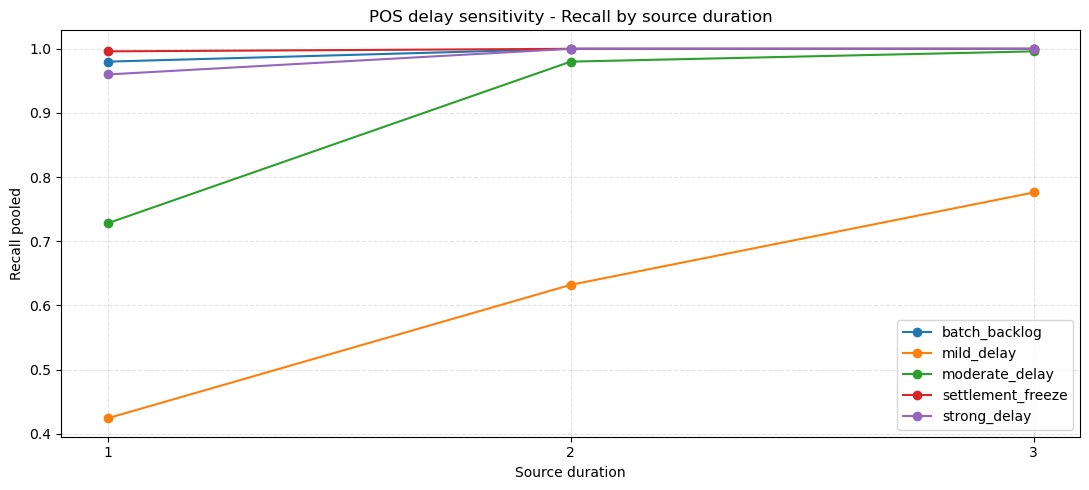

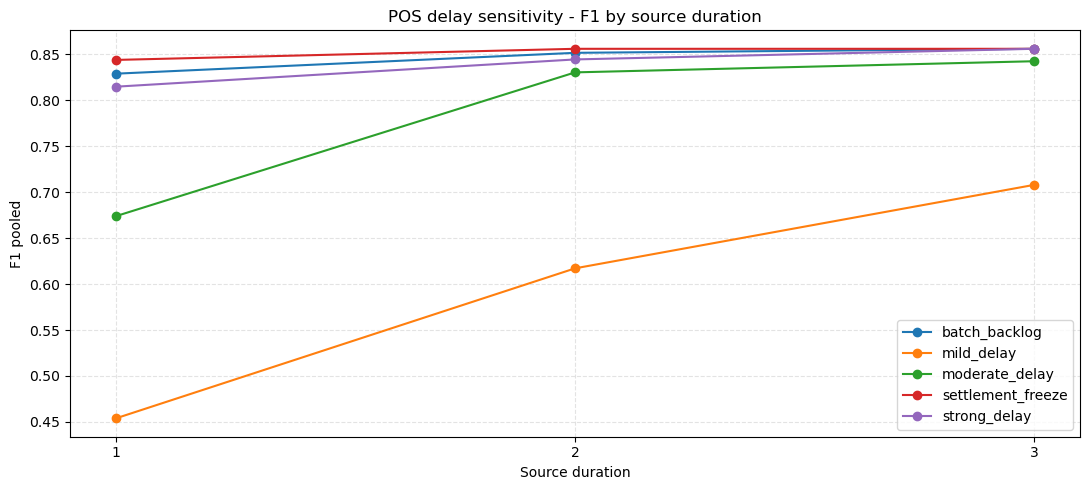

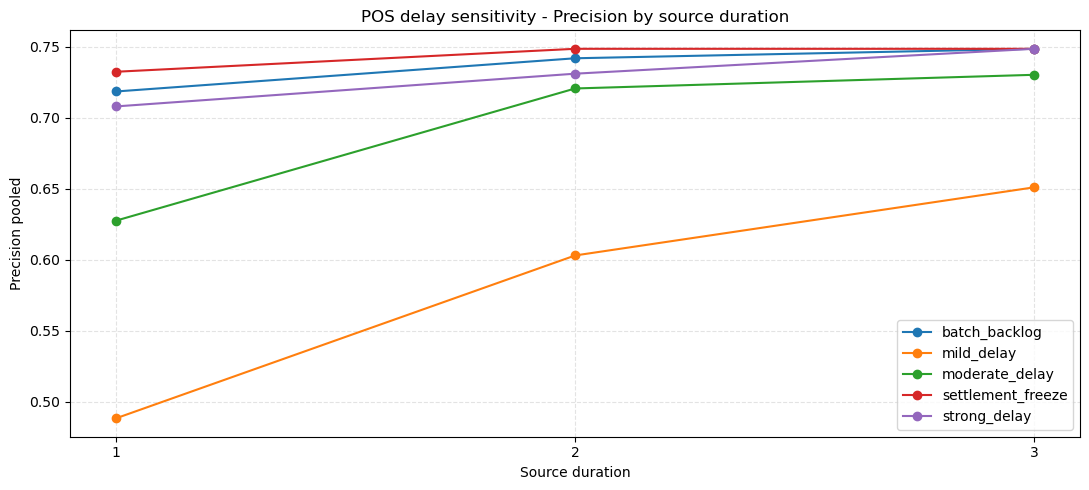

In [21]:
# =========================================================
# SOURCE DURATION FIGURES
# =========================================================

plot_metric_by_source_duration(
    by_type_duration,
    metric_col="recall_pooled",
    title="POS delay sensitivity - Recall by source duration",
    ylabel="Recall pooled",
    filename="secondary_recall_by_source_duration.png",
)

plot_metric_by_source_duration(
    by_type_duration,
    metric_col="f1_pooled",
    title="POS delay sensitivity - F1 by source duration",
    ylabel="F1 pooled",
    filename="secondary_f1_by_source_duration.png",
)

plot_metric_by_source_duration(
    by_type_duration,
    metric_col="precision_pooled",
    title="POS delay sensitivity - Precision by source duration",
    ylabel="Precision pooled",
    filename="secondary_precision_by_source_duration.png",
)

## Salvataggio delle tabelle aggregate

In [22]:
# =========================================================
# SAVE AGGREGATED RESULTS
# =========================================================

main_overall_path = OUTPUT_DIR / "main_source_duration_1_overall.csv"
main_by_type_path = OUTPUT_DIR / "main_source_duration_1_by_type.csv"

by_source_duration_path = OUTPUT_DIR / "secondary_by_source_duration.csv"
by_type_duration_path = OUTPUT_DIR / "secondary_by_type_and_source_duration.csv"

pivot_precision_path = OUTPUT_DIR / "pivot_precision_by_type_duration.csv"
pivot_recall_path = OUTPUT_DIR / "pivot_recall_by_type_duration.csv"
pivot_f1_path = OUTPUT_DIR / "pivot_f1_by_type_duration.csv"
pivot_iou_path = OUTPUT_DIR / "pivot_iou_by_type_duration.csv"

compact_metrics_by_duration_path = OUTPUT_DIR / "compact_metrics_by_type_duration.csv"

main_overall.to_csv(main_overall_path, index=False)
main_by_type.to_csv(main_by_type_path, index=False)

by_source_duration.to_csv(by_source_duration_path, index=False)
by_type_duration.to_csv(by_type_duration_path, index=False)

pivot_precision.to_csv(pivot_precision_path)
pivot_recall.to_csv(pivot_recall_path)
pivot_f1.to_csv(pivot_f1_path)
pivot_iou.to_csv(pivot_iou_path)
compact_metrics_by_duration.to_csv(compact_metrics_by_duration_path)

saved_paths = [
    main_overall_path,
    main_by_type_path,
    pos_delay_type_table_path,
    source_duration_table_path,
    by_source_duration_path,
    by_type_duration_path,
    pivot_precision_path,
    pivot_recall_path,
    pivot_f1_path,
    pivot_iou_path,
    compact_metrics_by_duration_path,
]

saved_paths

[WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/lstm_sensitivity/main_source_duration_1_overall.csv'),
 WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/lstm_sensitivity/main_source_duration_1_by_type.csv'),
 WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/lstm_sensitivity/pos_delay_type_summary_thesis.csv'),
 WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/lstm_sensitivity/pos_delay_source_duration_summary_thesis.csv'),
 WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/lstm_sensitivity/secondary_by_source_duration.csv'),
 WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/lstm_sensitivity/secondary_by_type_and_source_duration.csv'),
 WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay/lstm_sensitivity/pivot_precision_by_type_duration.csv'),
 WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/pos_delay